# Keras Linear Regression

In [1]:
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import metrics
from sklearn.metrics import mean_squared_error

sns.set_context('notebook')
sns.set_style('white')

ModuleNotFoundError: No module named 'tensorflow'

In this notebook we perform linear regression with Keras. For this we'll use a dataset for a bike sharing company that suffered losses during the pandemic. The goal is to figure out what the reason is for theses losses from a dataset of bike metrics:

> - instant: record index
> - dteday : date
> - season : season (1:winter, 2:spring, 3:summer, 4:fall)
> - yr : year (0: 2011, 1:2012)
> - mnth : month ( 1 to 12)
> - hr : hour (0 to 23)
> - holiday : whether day is holiday or not (extracted from [Web Link](https://dchr.dc.gov/page/holiday-schedules?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01))
> - weekday : day of the week
> - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
> - weathersit :(1) Clear, Few clouds, Partly cloudy, Partly cloudy, (2) Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist, (3) Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds, (4) Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
> - temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 
> - atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
> - hum: Normalized humidity. The values are divided to 100 (max)
> - windspeed: Normalized wind speed. The values are divided to 67 (max)
> - casual: count of casual users
> - registered: count of registered users
> - cnt: count of total rental bikes including both casual and registered

In [10]:

df = pd.read_csv('./data/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [11]:
df.shape, list(zip(df.columns, df.dtypes))

((731, 16),
 [('instant', dtype('int64')),
  ('dteday', dtype('O')),
  ('season', dtype('int64')),
  ('yr', dtype('int64')),
  ('mnth', dtype('int64')),
  ('holiday', dtype('int64')),
  ('weekday', dtype('int64')),
  ('workingday', dtype('int64')),
  ('weathersit', dtype('int64')),
  ('temp', dtype('float64')),
  ('atemp', dtype('float64')),
  ('hum', dtype('float64')),
  ('windspeed', dtype('float64')),
  ('casual', dtype('int64')),
  ('registered', dtype('int64')),
  ('cnt', dtype('int64'))])

We'll remove the following columns:
- `dteday`, non-numerical
- `instant`, only a row index number, not meaningful otherwise
- `casual` and `registered`, both part of the target variable `cnt`

In [12]:
target = "cnt"
remove = ["dteday", "casual", "registered", "instant"]

df = df.drop(columns=remove)
X = df.drop(columns=target).to_numpy()
y = df[target].to_numpy().flatten()


## EDA

### Bivariate Analysis

First we'll inspect the data to see if anything obvious jumps out. This is done by making regplots against the cnt variable.

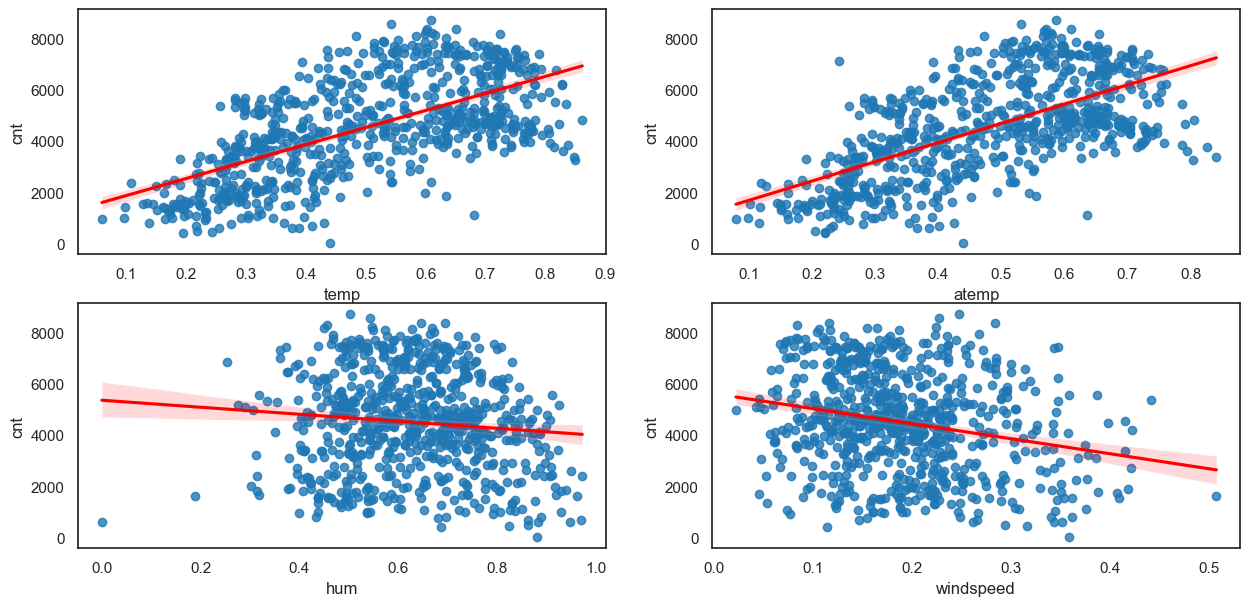

In [14]:
col = ['temp', 'atemp', 'hum', 'windspeed']
plt.figure(figsize=[15,7])
for i in enumerate(col):
    plt.subplot(2,2,i[0]+1)
    sns.regplot(data=df,x=i[1],y='cnt',line_kws={"color":'red'})
    
plt.show()

So at least there is a positive correlation with the temperature and a negative corealtion with the wind speed. There may also be a slight negative corelation with the humidity, but this effect is smaller.

We can also do the same analysis on the categorical variables:

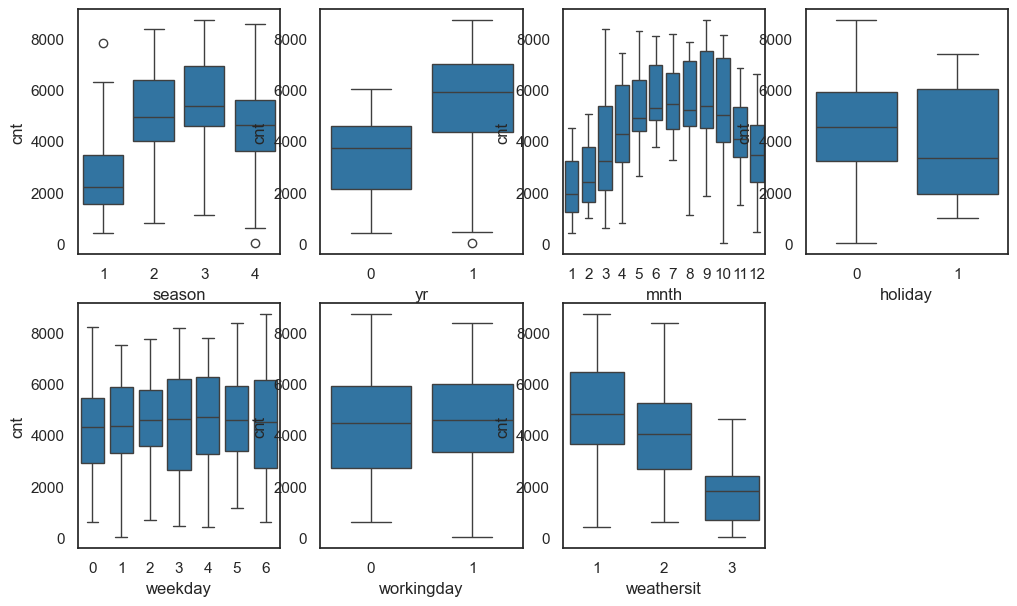

In [16]:
col = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
plt.figure(figsize=[12, 7])
for i in enumerate(col):
    plt.subplot(2, 4, i[0]+1)
    sns.boxplot(data=df, x=i[1], y='cnt')
    
plt.show()

From this we can already see a correlation with the season (more likely to rent out bikes in fall), which is also reflected in the months. It is slightly more likely to rent out bikes on non-holiday days, though there is overlap in the variance. Clear weather is preferred and there is no effect of the day of the week.

### Multivariate Analysis

Seaborn makes doing multivariate analysis very easy by providing us with the pairplot function, which plots all columns against each other.

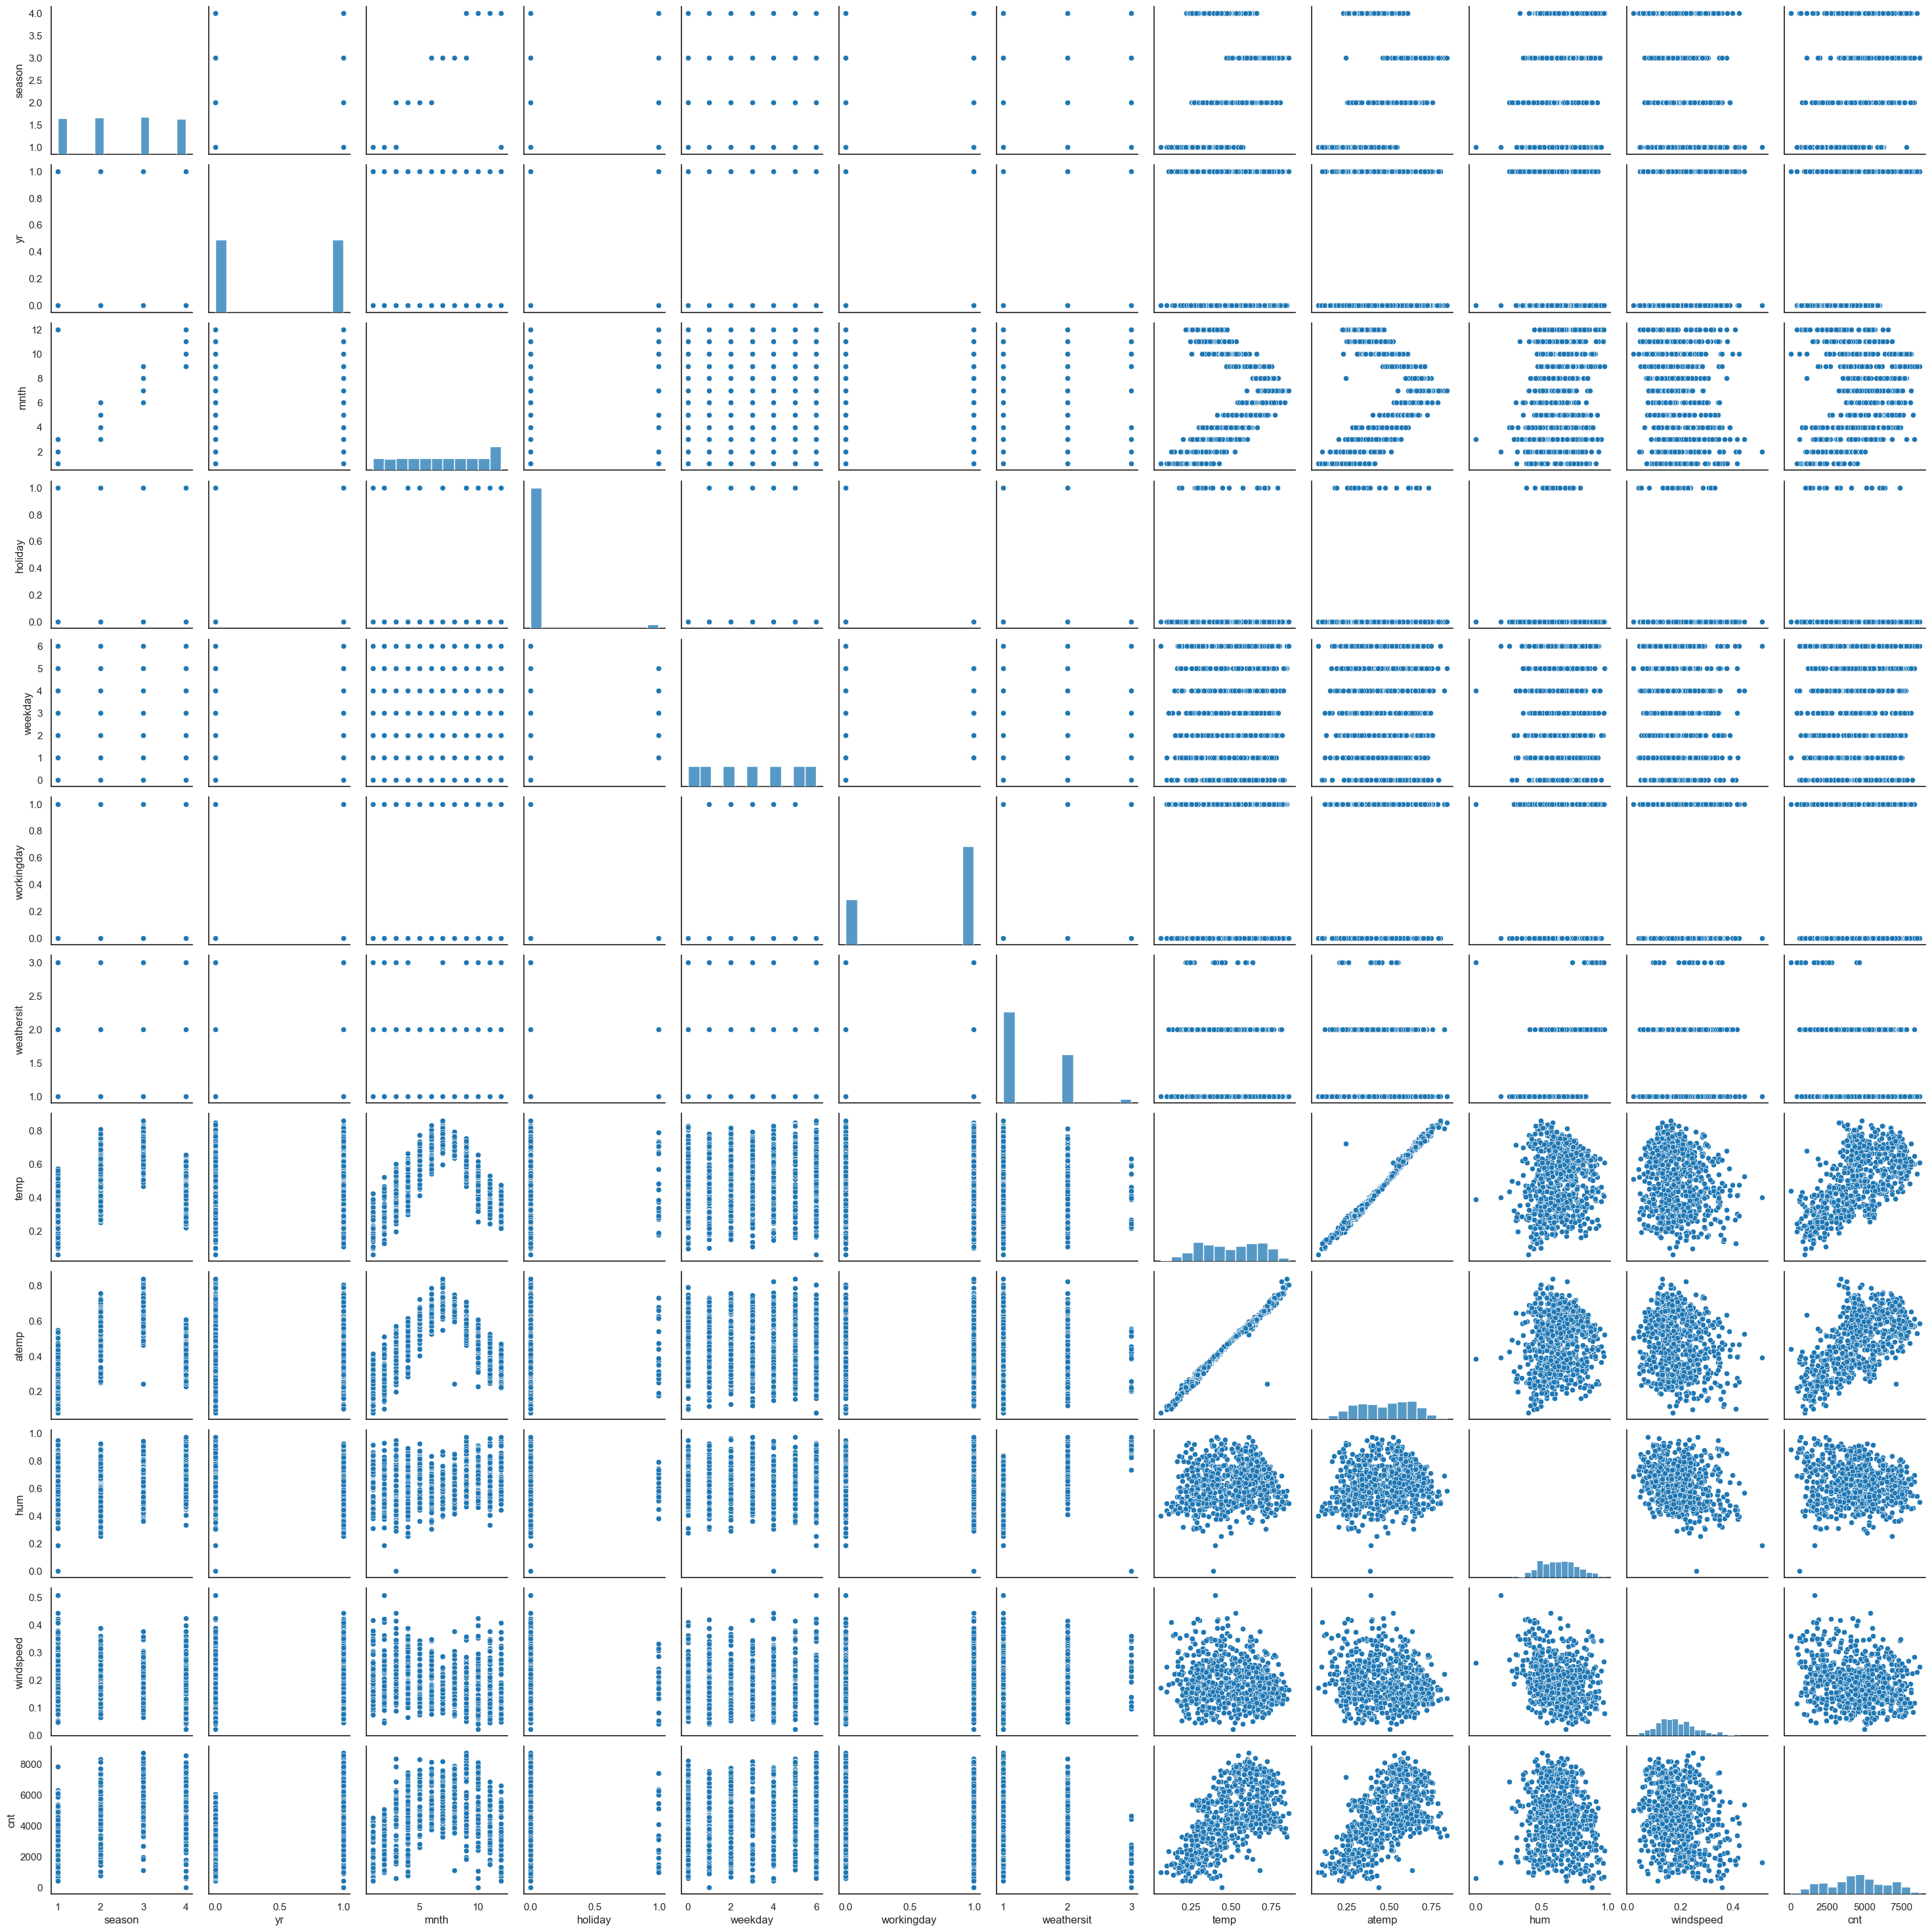

In [17]:
sns.pairplot(df)

This shows us the same information as before, so no real additional insight is gained here, apart from having it all in one graph.

### Column Heatmap

To check out the correlations more meaningfully, we can build a heatmap from the correlation matrix.

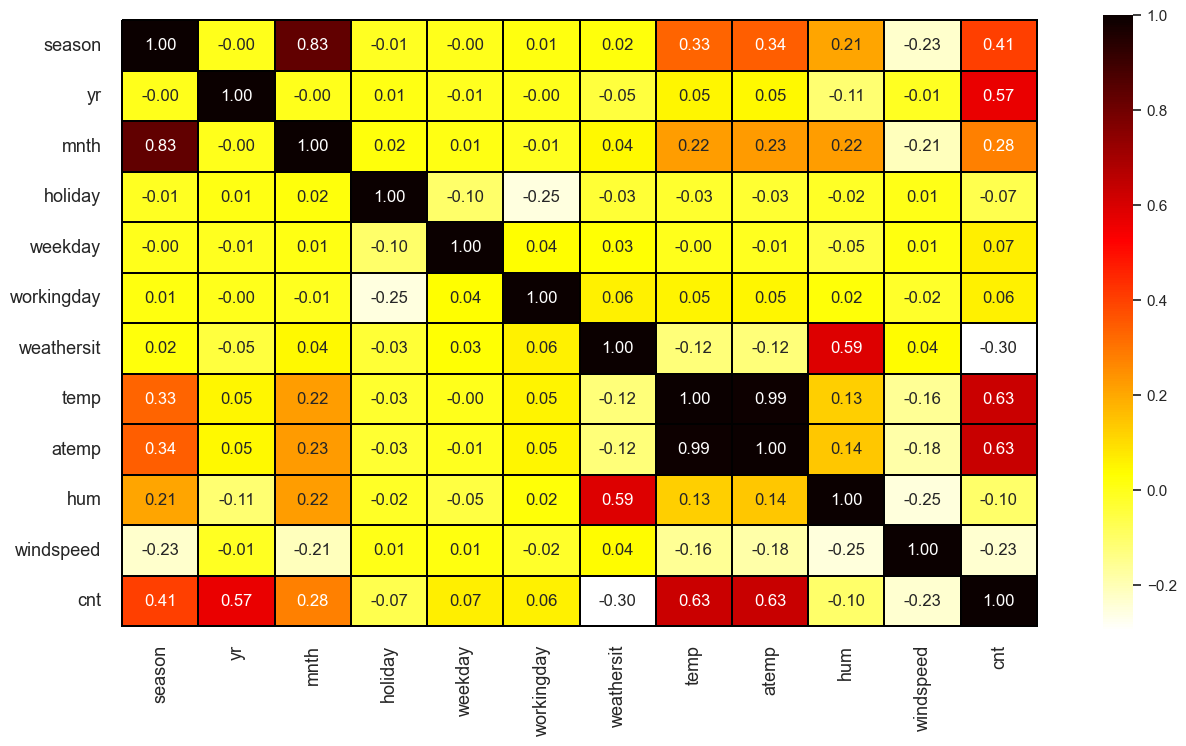

In [18]:
plt.figure(figsize=[15,8])
fig = sns.heatmap(df.corr(),cmap='hot_r',
            annot=True,linecolor='black',linewidths=0.01,annot_kws={"fontsize":12},fmt="0.2f")

top, bottom = fig.get_ylim()
fig.set_ylim(top+0.1,bottom-0.1)

left, right = fig.get_xlim()
fig.set_xlim(left-0.1,right+0.1) 

plt.yticks(fontsize=13,rotation=0)
plt.xticks(fontsize=13,rotation=90);

This confirms our earlier conclusion that there is a correlation between the target variable and the following features: 
- Season
- Year
- month (lesser)
- weather (lesser negative)
- temperature
- windspeed (lesser negative)

## Preprocessing

Now we know more about our data, we can start preprocessing. First we'll split the data into train/test. Then we normalize since the features use different scales. This is done with the keras normalization layer, as part of the network.

In [19]:
train_dataset = df.sample(frac=0.8, random_state=0)
test_dataset = df.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('cnt')
test_labels = test_features.pop('cnt')

In [20]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

## Linear Regression

Linear regression is the same as having a neural network with a single node and no activation function. So we build this exact network below. The input layer is the same size as the number of features, and will first pass through a normalisation layer.

First, we'll just use the temperature as an input to predict the `cnt` value.

In [ ]:
temp = np.array(train_features['temp'])
temp_norm = layers.Normalization(axis=None)
temp_norm.adapt(temp)

In [27]:
temp_model = tf.keras.Sequential(
    [
        layers.Input((1, )),
        layers.Normalization(),
        layers.Dense(1)
    ]
)

temp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

Then we compile the model with an optimizer and a loss function, and then train it.

In [28]:
temp_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error')

In [32]:
history = temp_model.fit(
    train_features['temp'],
    train_labels,
    # to view the logs, uncomment this:
    verbose=False,
    epochs=100,
    # validation split: 20% of the training data.
    validation_split = 0.2)

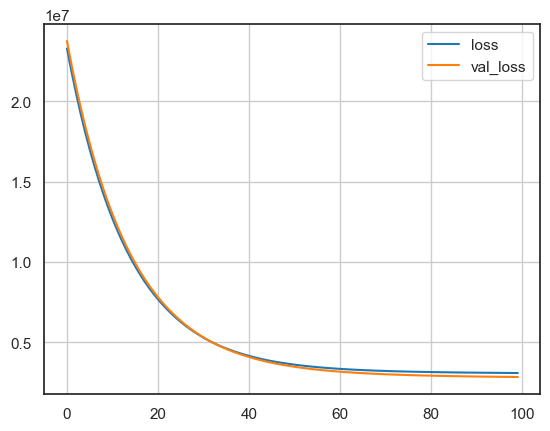

In [30]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend()
    plt.grid(True)
plot_loss(history)

Finally, we can make some predictions using the model by taking the predictions and plotting them as function of the temperature.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1586.3406002495176


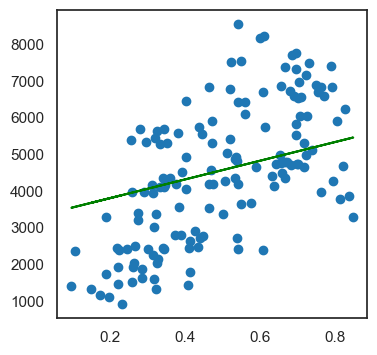

In [33]:
y_pred = temp_model.predict(test_features['temp'])
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))
plt.figure(figsize = (4,4))
plt.plot(test_features['temp'], test_labels,'o',
         test_features['temp'], y_pred,'g');

### Linear regression with multiple inputs

Scaling this to more features is extremely simple, we only have to upgrade the input layer and the network takes care of the rest. We have previously already trained a normaliser layer on the required features, so we can use that one directly.

In [38]:
linear_model = tf.keras.Sequential(
    [
        normalizer,
        layers.Dense(1)
    ]
)

linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error')

linear_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (585, 11)              │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (96.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23 (96.00 B)

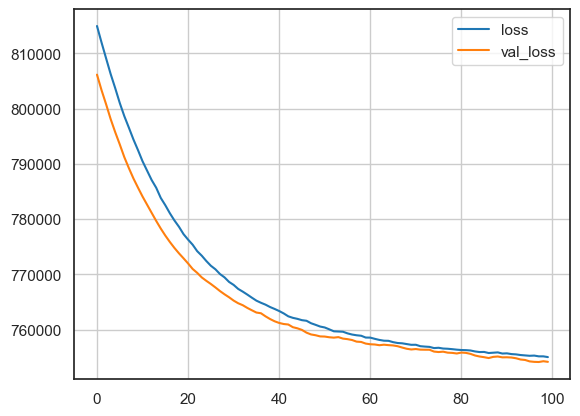

In [40]:
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # to view the logs, uncomment this:
    verbose=0,
    # validation split: 20% of the training data.
    validation_split = 0.2)

plot_loss(history)

From this we can see that a much lower validation error waws achieved by using the full dataset as features.

In [43]:
y_pred = linear_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

print("Column names")
print(test_features.columns.to_list())

# Print weights and biases for each layer
for layer in linear_model.layers:
    print("Layer Name:", layer.name)
    print("---")
    print("Weights")
    print("Shape:",layer.get_weights()[0].shape,'\n',layer.get_weights()[0])
    print("---")
    print("Bias")
    print("Shape:",layer.get_weights()[1].shape,'\n',layer.get_weights()[1],'\n')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
884.6069042235653
Column names
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Layer Name: normalization
---
Weights
Shape: (11,) 
 [2.4820514  0.50598294 6.557265   0.02735043 2.9931624  0.6803419
 1.4        0.49609548 0.47542128 0.6289289  0.19085288]
---
Bias
Shape: (11,) 
 [1.2274556e+00 2.4996421e-01 1.1894584e+01 2.6602382e-02 4.0580730e+00
 2.1747680e-01 2.9811966e-01 3.2840721e-02 2.6041929e-02 2.0187266e-02
 6.0876710e-03] 

Layer Name: dense_6
---
Weights
Shape: (11, 1) 
 [[ 438.08795]
 [1037.036  ]
 [ -23.89733]
 [-139.565  ]
 [ 150.65114]
 [  75.39654]
 [-336.4336 ]
 [ 471.17017]
 [ 526.9141 ]
 [-173.0697 ]
 [-214.36258]]
---
Bias
Shape: (1,) 
 [4509.1875] 



## Neural Networks for Regression

Here we use the Iowa Housing dataset to predict sale price from square feet./

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - loss: 8050992640.0000 
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - loss: 3713485824.0000
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 3595562752.0000
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - loss: 4535346176.0000
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - loss: 3577881856.0000
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - loss: 3714576896.0000
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 3367305216.0000
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - loss: 3972096000.0000
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - loss: 3386614016.0000
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - loss: 3435739136.0000
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - loss: 3348232960.0000
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 3319116288.0000
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 3366720256.0000
Epoch 1

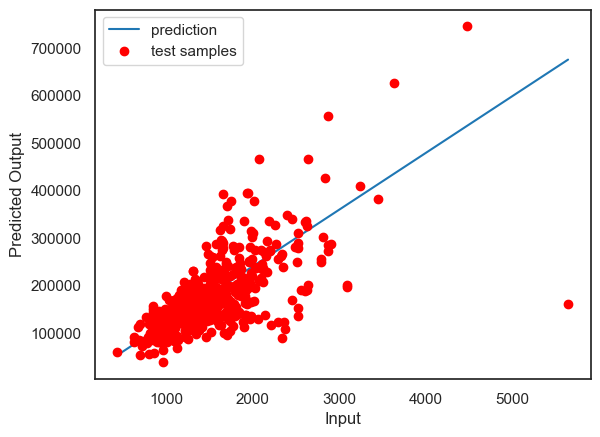

In [48]:
df = pd.read_csv("./data/IowaHousingPrices.csv")

x_train = df[['SquareFeet']].values[1:-500]
y_train = df[['SalePrice']].values[1:-500]
x_test = df[['SquareFeet']].values[-500:]
y_test = df[['SalePrice']].values[-500:]

output_size = 1
hidden_layer = 500
input_size = 1
learning_rate = 0.51
loss_function = 'mean_squared_error'
epochs = 30
batch_size = 10

model = keras.Sequential()
model.add(layers.Input((1, )))
model.add(layers.Dense(hidden_layer,  activation='relu'))
model.add(layers.Dense(output_size))

model.compile(keras.optimizers.Adam(learning_rate=learning_rate), loss_function)

model.fit(x_train, y_train, epochs = epochs, batch_size = batch_size)

x = np.arange(x_test.min(),x_test.max(),10).reshape(-1,1)
y_pred = model.predict(x)

plt.plot(x,y_pred,label="prediction ")
plt.plot(x_test,y_test,'ro',label="test samples")
plt.xlabel('Input')
plt.ylabel('Predicted Output')
plt.legend()
plt.show()

## Predicting Fuel Efficiency of cars with Keras Linear Regression

In [102]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']
df = pd.read_csv("./data/auto-mpg.data", names=column_names, sep=r"\s+")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 18.0 to 31.0
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    int64  
 1   Cylinders     398 non-null    float64
 2   Displacement  398 non-null    object 
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    int64  
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 28.0+ KB


In [103]:
df = df.dropna()
df = df[df.Displacement != "?"]
df = df.drop(columns=["Origin"])
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year
18.0,8,307.0,130.0,3504.0,12.0,70,1
15.0,8,350.0,165.0,3693.0,11.5,70,1
18.0,8,318.0,150.0,3436.0,11.0,70,1
16.0,8,304.0,150.0,3433.0,12.0,70,1
17.0,8,302.0,140.0,3449.0,10.5,70,1


In [104]:
train_dataset = df.sample(frac=0.8, random_state=0)
test_dataset = df.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

In [106]:
car_norm = layers.Normalization(axis=-1)
car_norm.adapt(np.array(train_features, dtype=np.float64))

In [107]:
car_model = tf.keras.Sequential(
    [
        car_norm,
        layers.Dense(1)
    ]
)

car_model.compile(tf.keras.optimizers.SGD(learning_rate=0.003), "binary_crossentropy")

car_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_12                │ (314, 6)               │            13 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (56.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 13 (56.00 B)

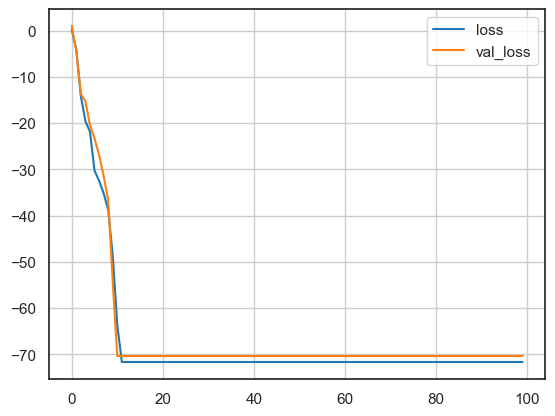

In [109]:
history = car_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # to view the logs, uncomment this:
    verbose=0,
    # validation split: 20% of the training data.
    validation_split = 0.2)

plot_loss(history)

In [111]:
y_pred = car_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2.748551767651104
